# Binary Classification with CNNs: pneumonia_MNIST Data Set

## Setup

In [1]:
import numpy as np
import seaborn as sb
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

import datetime

notebook_start_time = datetime.datetime.now()

2025-05-12 13:54:15.297973: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-12 13:54:15.425354: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747072455.472015   13139 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747072455.484819   13139 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747072455.590391   13139 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# load the dataset
import tensorflow_datasets as tfds

train_ds, validation_ds, test_ds = tfds.load(
    "pneumonia_mnist", split=["train", "val", "test"], as_supervised=True
)

batch_size = 32
train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
validation_ds = validation_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

metrics = [
    tf.keras.metrics.TruePositives(name="tp"),
    tf.keras.metrics.TrueNegatives(name="tn"),
    tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
]

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="best_model.keras", save_best_only=True, monitor="val_loss", mode="min"
)

epochs = 10

# images are batched, so we need to extract them
y_true = tf.concat([y for x, y in test_ds], axis=0)

2025-05-12 13:54:17.443815: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-05-12 13:54:17.662594: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2025-05-12 13:54:17.675031: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [3]:
def summary_graphics(history, model):
    y_pred = np.round(model.predict(test_ds))
    fig, ax = plt.subplots(1, 3)
    fig.set_size_inches(16, 5)
    ax = ax.flatten()

    # true/false positive/negative rates (better than accuracy for imbalanced data!)
    ax[0].plot(history.history["tp"], label="True Positives", color="g")
    # ax[0].plot(history.history['fp'], label = 'False Positives')
    ax[0].plot(history.history["tn"], label="True Negatives", color="r")
    # ax[0].plot(history.history['fn'], label = 'False Negatives', color='orange')
    ax[0].grid(True)
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Metric Value")
    ax[0].legend(loc="right")
    ax[0].set_title("True Positive and True Negative Rates")

    # loss
    ax[1].plot(history.history["loss"], label="Loss")
    ax[1].plot(history.history["val_loss"], label="Val Loss")
    ax[1].grid(True)
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].legend(loc="upper right")
    ax[1].set_title("Loss")

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sb.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[2])
    ax[2].set_xlabel("Predicted")
    ax[2].set_ylabel("True")
    ax[2].xaxis.set_ticklabels(
        [
            f"Normal ({(cm[0][0] + cm[1][0])/len(y_pred):.3f})",
            f"Pneumonia ({(cm[0][1] + cm[1][1])/len(y_pred):.3f})",
        ]
    )
    ax[2].yaxis.set_ticklabels(
        [
            f"Normal ({(cm[0][0] + cm[0][1])/len(y_pred):.3f})",
            f"Pneumonia ({(cm[1][0] + cm[1][1])/len(y_pred):.3f})",
        ]
    )
    ax[2].set_title("Confusion Matrix")

    plt.show()


def plot_confusion_matrix(
    y_true, X_test, model, classes, title="Confusion matrix", cmap=plt.cm.Blues
):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=len(classes))
    cm = cm.numpy()
    cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(10, 10))
    plt.imshow(cm, interpolation="nearest", cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    threshold = cm.max() / 2.0
    for i, j in np.ndindex(cm.shape):
        plt.text(
            j,
            i,
            format(cm[i, j], ".2f"),
            horizontalalignment="center",
            color="white" if cm[i, j] > threshold else "black",
        )

    plt.tight_layout()
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()


def get_class_training_weights(assignments, normalize=True):
    # my normal function doesn't work with the tf.data.Dataset object, so I'm writing a new one
    weight_1 = sum(assignments) / len(assignments)
    weight_0 = 1 - weight_1
    if normalize:
        denom = max(weight_1, weight_0)
        weight_1 = weight_1 / denom
        weight_0 = weight_0 / denom
    return {0: weight_0, 1: weight_1}

In [4]:
class_weight = get_class_training_weights(tf.concat([y for x, y in train_ds], axis=0))

print(f"Weight for normal class: {class_weight[0]:1.3f}")
print(f"Weight for pneumonia class: {class_weight[1]:1.3f}")

2025-05-12 13:54:17.945255: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Weight for normal class: 0.347
Weight for pneumonia class: 1.000


## Training

In [5]:
model_1 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((28, 28, 1), name="input"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(1000, activation="relu", name="5.2dense"),
        tf.keras.layers.Dense(500, activation="relu", name="5.4dense"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_1",
)

model_1.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

model_1.summary()

Model: "Model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 5.1flatten (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.2dense (Dense)                │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.4dense (Dense)                │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286,001 (4.91 MB)

 Trainable params: 1,286,001 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model_1.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8153 - loss: 9.0946 - precision: 0.8413 - recall: 0.9261 - tn: 344.1208 - tp: 1677.5906 - val_accuracy: 0.9504 - val_loss: 0.6751 - val_precision: 0.9642 - val_recall: 0.9692 - val_tn: 121.0000 - val_tp: 377.0000
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8972 - loss: 1.0643 - precision: 0.9044 - recall: 0.9632 - tn: 426.9799 - tp: 1708.6309 - val_accuracy: 0.9179 - val_loss: 1.1316 - val_precision: 0.9915 - val_recall: 0.8972 - val_tn: 132.0000 - val_tp: 349.0000
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8991 - loss: 1.0262 - precision: 0.9086 - recall: 0.9607 - tn: 438.5839 - tp: 1708.3221 - val_accuracy: 0.8912 - val_loss: 1.6237 - val_precision: 0.9911 - val_recall: 0.8612 - val_tn: 132.0000 - val_tp: 335.0000
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8903 - loss: 1.3081 - precision: 0.8994 - recall: 0.9594 - tn: 420.7383 - tp: 1705.5033 - val_acc

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


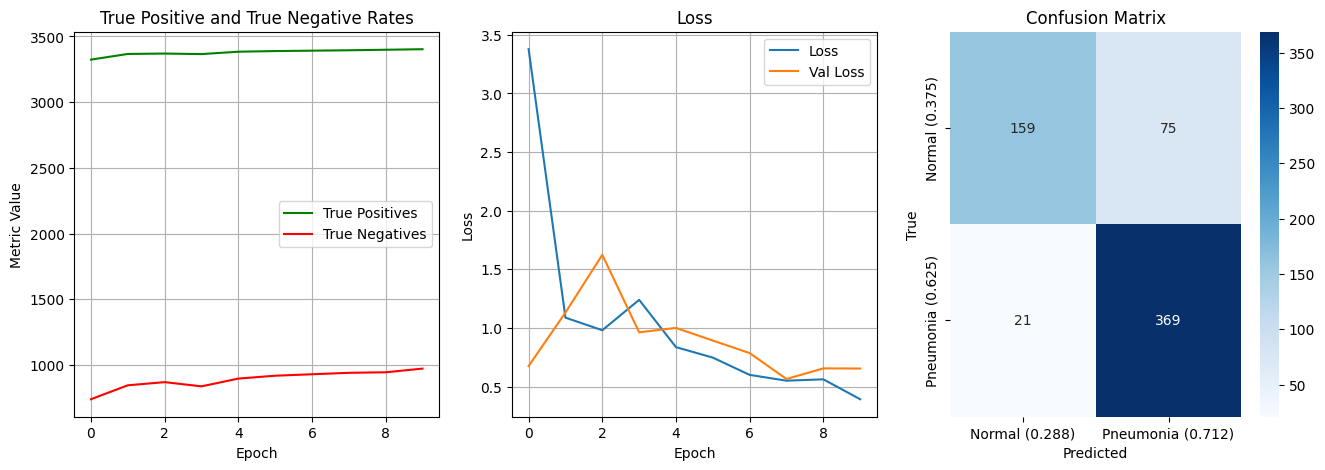

In [7]:
summary_graphics(history, model_1)

In [13]:
# try something similar to xception, but with fewer filters and layers
# to account for how small these images are
model_2 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((28, 28, 1), name="input"),
        tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(512, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.7, name="5.3dropout"),
        tf.keras.layers.Dense(256, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.5, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_2",
)

model_2.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

model_2.summary()

Model: "Model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 0.1rflip (RandomFlip)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 0.2rrot (RandomRotation)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 0.3rtran (RandomTranslation)    │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.1conv (Conv2D)                │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.2conv (Conv2D)                │ (None, 28, 28, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.3pool (MaxPooling2D)          │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.1conv (Conv2D)                │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.2conv (Conv2D)                │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.3pool (MaxPooling2D)          │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.1conv (SeparableConv2D)       │ (None, 7, 7, 64)       │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.2batchnorm                    │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.3conv (SeparableConv2D)       │ (None, 7, 7, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.4pool (MaxPooling2D)          │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.1conv (SeparableConv2D)       │ (None, 4, 4, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.2batchnorm                    │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.3conv (SeparableConv2D)       │ (None, 4, 4, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.6pool (MaxPooling2D)          │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.1flatten (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.2dense (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.3dropout (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.4dense (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.5dropout (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           25

 Total params: 296,657 (1.13 MB)

 Trainable params: 296,401 (1.13 MB)

 Non-trainable params: 256 (1.00 KB)

In [14]:
history = model_2.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7780 - loss: 0.4430 - precision: 0.7755 - recall: 0.9868 - tn: 246.9732 - tp: 4196.5840 - val_accuracy: 0.7424 - val_loss: 0.6350 - val_precision: 0.7424 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 389.0000
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7401 - loss: 0.2182 - precision: 0.7399 - recall: 0.9997 - tn: 5.6980 - tp: 1775.5906 - val_accuracy: 0.7424 - val_loss: 0.6219 - val_precision: 0.7424 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 389.0000
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8211 - loss: 0.1576 - precision: 0.8134 - recall: 0.9846 - tn: 250.8121 - tp: 1744.3759 - val_accuracy: 0.2710 - val_loss: 0.7219 - val_precision: 1.0000 - val_recall: 0.0180 - val_tn: 135.0000 - val_tp: 7.0000
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8680 - loss: 0.1507 - precision: 0.8678 - recall: 0.9689 - tn: 358.7852 - tp: 1719.1677 - val

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


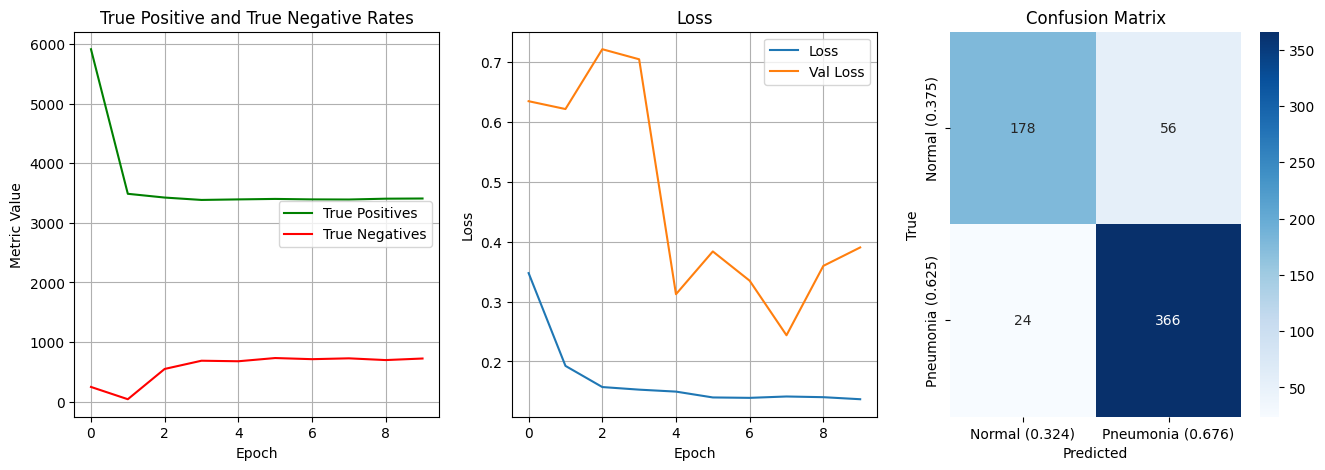

In [ ]:
# validation accuracy and loss seem to be randomly crashing, so let's use the best model instead of just the last one
best_model = tf.keras.models.load_model("best_model.keras")
summary_graphics(history, best_model)

In [19]:
# model accuracy seems to be capping out, so let's lower dropout slightly
model_3 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((28, 28, 1), name="input"),
        tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(512, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.5, name="5.3dropout"),
        tf.keras.layers.Dense(256, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.4, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_3",
)

model_3.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8342 - loss: 0.4442 - precision: 0.8278 - recall: 0.9815 - tn: 639.9933 - tp: 4589.4834 - val_accuracy: 0.7424 - val_loss: 0.6202 - val_precision: 0.7424 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 389.0000
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7440 - loss: 0.2139 - precision: 0.7431 - recall: 0.9991 - tn: 24.2685 - tp: 1773.4833 - val_accuracy: 0.7424 - val_loss: 0.6194 - val_precision: 0.7424 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 389.0000
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8673 - loss: 0.1480 - precision: 0.8687 - recall: 0.9664 - tn: 361.3758 - tp: 1718.6980 - val_accuracy: 0.8912 - val_loss: 0.5550 - val_precision: 0.9560 - val_recall: 0.8946 - val_tn: 119.0000 - val_tp: 348.0000
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8776 - loss: 0.1389 - precision: 0.8764 - recall: 0.9715 - tn: 368.5570 - tp: 1725.1544 - 

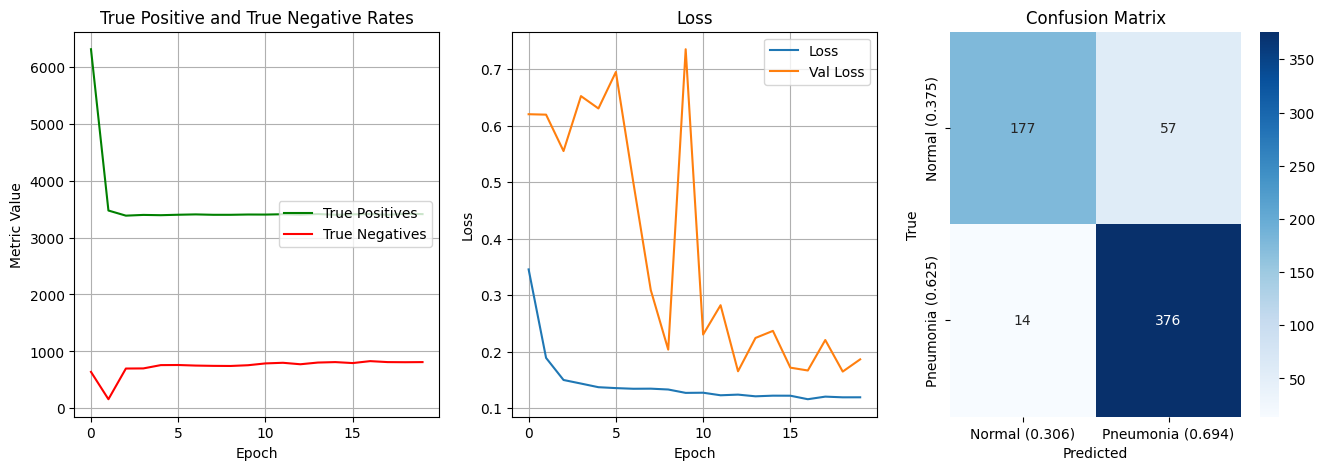

In [20]:
history = model_3.fit(
    train_ds,
    validation_data=validation_ds,
    batch_size=batch_size,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)
best_model = tf.keras.models.load_model("best_model.keras")
summary_graphics(history, best_model)

Epoch 1/20


148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9026 - loss: 0.1097 - precision: 0.9003 - recall: 0.9765 - tn: 422.4765 - tp: 1735.3490 - val_accuracy: 0.9370 - val_loss: 0.1733 - val_precision: 0.9258 - val_recall: 0.9949 - val_tn: 104.0000 - val_tp: 387.0000
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9069 - loss: 0.1094 - precision: 0.9088 - recall: 0.9717 - tn: 437.2215 - tp: 1728.1276 - val_accuracy: 0.9046 - val_loss: 0.2153 - val_precision: 0.9857 - val_recall: 0.8843 - val_tn: 130.0000 - val_tp: 344.0000
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9039 - loss: 0.1084 - precision: 0.9028 - recall: 0.9749 - tn: 432.4497 - tp: 1733.3960 - val_accuracy: 0.9008 - val_loss: 0.2279 - val_precision: 0.8874 - val_recall: 0.9923 - val_tn: 86.0000 - val_tp: 386.0000
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9047 - loss: 0.1073 - precision: 0.9072 - recall: 0.9706 - tn: 435.8725 - tp: 1726.6241 - val_accuracy: 0

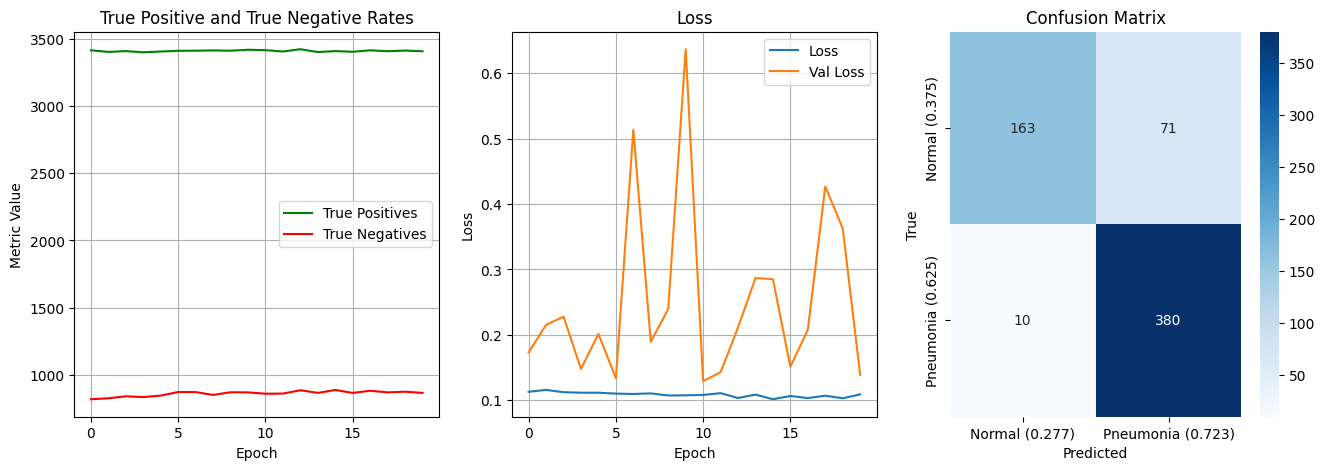

In [21]:
# maybe more epochs will help
epochs = 20
history = model_3.fit(
    train_ds,
    validation_data=validation_ds,
    batch_size=batch_size,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)
summary_graphics(history, model_3)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


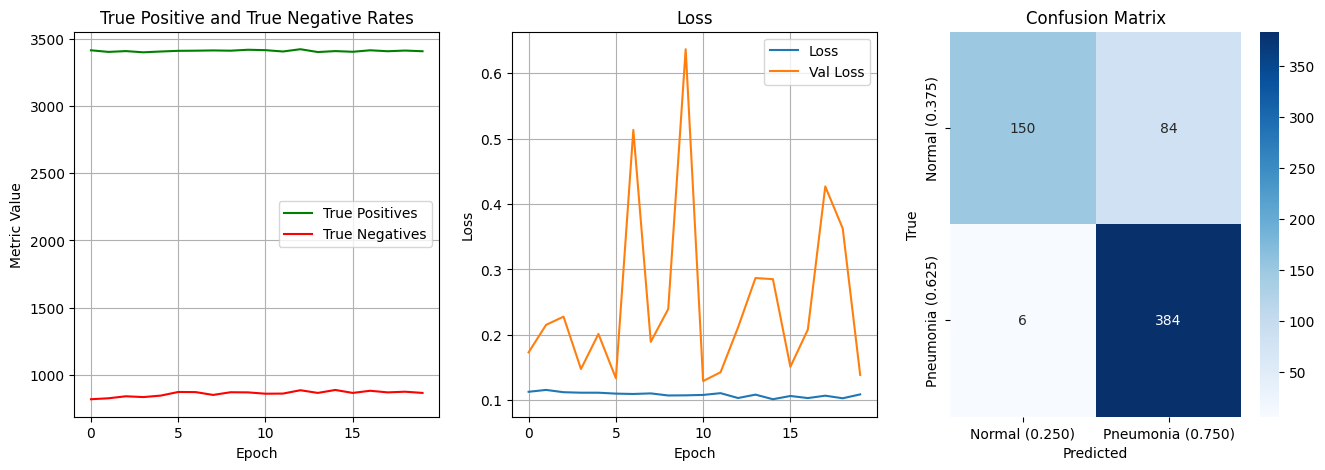

In [22]:
best_model = tf.keras.models.load_model("best_model.keras")
summary_graphics(history, best_model)

In [23]:
notebook_end_time = datetime.datetime.now()
print(
    f"Notebook last run (end-to-end): {notebook_end_time} (duration: {notebook_end_time - notebook_start_time})"
)

Notebook last run (end-to-end): 2025-05-12 13:59:30.629830 (duration: 0:05:13.436244)
